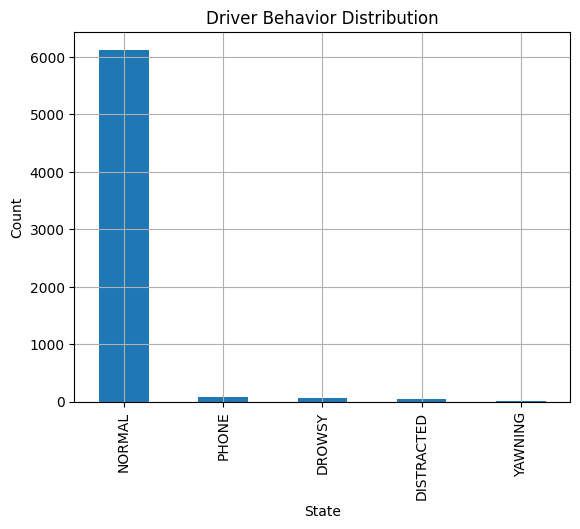

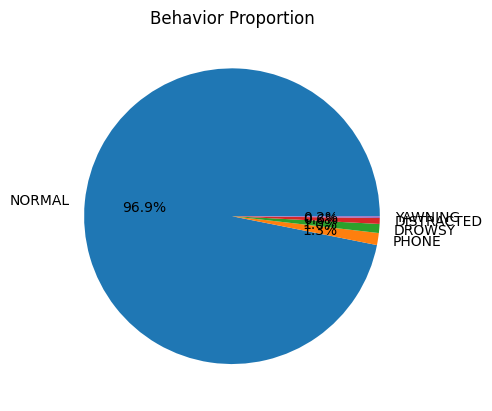

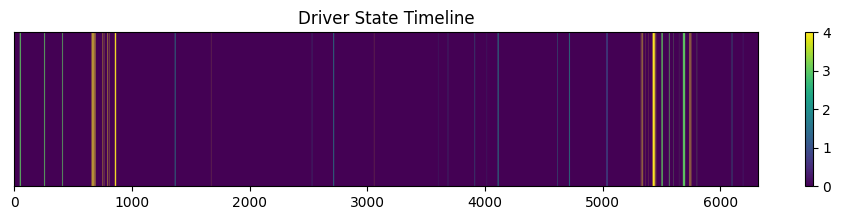

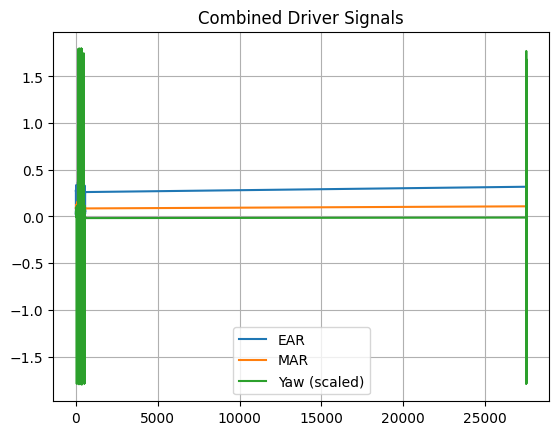

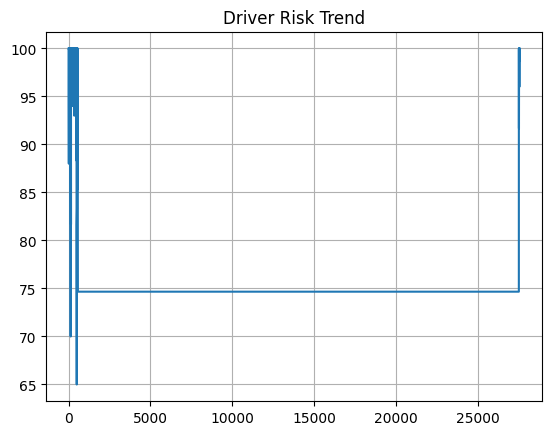

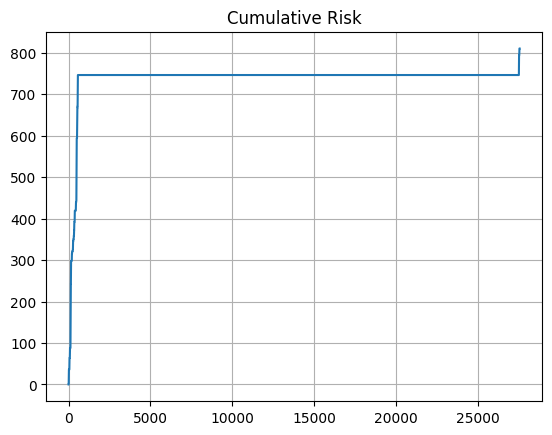


------ DRIVER REPORT ------
Total Frames: 6324

State Distribution (%):
state
NORMAL        96.87
PHONE          1.31
DROWSY         0.98
DISTRACTED     0.65
YAWNING        0.19
Name: count, dtype: float64

Final Safety Score: 97.44


In [13]:
# -------------------- IMPORTS --------------------
import cv2                                      # OpenCV for video processing
import torch                                    # For GPU/CPU selection
from ultralytics import YOLO                    # YOLOv8 object detection "You Only Look Once" # Fast For object detection 
import winsound                                 # Alert sound (Windows only)
import mediapipe as mp                          # Face landmark detection
from mediapipe.tasks import python              # Core MediaPipe Tasks API (base utilities, configs)
from mediapipe.tasks.python import vision       # Vision module (face, hand, object detection models)
import numpy as np                              # Numerical operations
import math                                     # Distance & angle calculations
import time                                     # Timestamp tracking
import pandas as pd                             # Data logging & analysis
import os                                       # File handling
import matplotlib.pyplot as plt                 # Visualization


# -------------------- CONFIG --------------------
FACE_MODEL_PATH = r"C:\Users\kurak\Downloads\face_landmarker.task"     # Path to the pre-trained face landmark model file
YOLO_MODEL = "yolov8m.pt"                                              # YOLOv8 model file used for object detection

# Thresholds for detection logic
EAR_THRESHOLD = 0.22        # Eye Aspect Ratio, Eye closure threshold (drowsiness)
MAR_THRESHOLD = 0.60        # Mouth Aspect Ratio, Mouth open threshold (yawning)
YAW_THRESHOLD = 40          # Yaw Angle, Yaw - the type of rotation (left ↔ right) Angle - how much rotation(movement) In degrees
PITCH_THRESHOLD = 40        # Pitch Angle, Pitch - the type of movement(up ↔ down) Angle - how much movement In degrees

# Frame counters (to avoid false positives)
EAR_FRAMES = 30             # Eyes must remain closed for 30 consecutive frames → Drowsy
MAR_FRAMES = 30             # Mouth must remain open for 30 consecutive frames → Yawning
DIST_FRAMES = 40            # Head must be turned for 40 frames → Distracted


# -------------------- INITIALIZATION --------------------
def init_models():
    """
    Initialize Mediapipe face landmark model and YOLO model
    """
    base = python.BaseOptions(model_asset_path=FACE_MODEL_PATH)     #Loads the face model file and sets it as base configuration for MediaPipe

    # Configure face detection
    opts = vision.FaceLandmarkerOptions(
        base_options=base,
        running_mode=vision.RunningMode.VIDEO,
        num_faces=1
    )                                                               # Configure face landmark detection (video mode, uses model, detects 1 face)

    face_detector = vision.FaceLandmarker.create_from_options(opts) # Create face landmark detector using the configured options

    # Selecting GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"         # Use GPU if available, otherwise use CPU

    # Load YOLO model "You Only Look Once"
    model = YOLO(YOLO_MODEL)                                        # Load YOLO model for object detection
    model.to(device)                                                # Move the model to the selected device (GPU or CPU)

    return face_detector, model, device                             # Return initialized face detector, YOLO model, and device


# -------------------- FEATURE FUNCTIONS --------------------
def dist(lm, a, b):
    """
    Calculate Euclidean distance between two facial landmarks
    """
    return math.dist((lm[a].x, lm[a].y), (lm[b].x, lm[b].y))      # Returns distance between two facial landmark points (a and b)


def compute_ear(lm):     # Calculates average eye openness using landmarks to detect drowsiness
    """
    Eye Aspect Ratio (EAR)
    Used to detect eye closure → Drowsiness
    """
    right = (dist(lm,161,163)+dist(lm,159,145)+dist(lm,157,154)) / (3*dist(lm,33,133))
    left  = (dist(lm,384,381)+dist(lm,386,374)+dist(lm,388,390)) / (3*dist(lm,362,263))
    return (right + left) / 2            # Return average EAR of both eyes


def compute_mar(lm):    # Calculates mouth opening ratio (MAR) to detect yawning
    """
    Eye Aspect Ratio (EAR)
    Used to detect eye closure → Drowsiness
    """
    return (dist(lm,13,14)+dist(lm,82,178)+dist(lm,312,402)) / (3*dist(lm,78,308))  # Return mouth opening ratio using vertical and horizontal distances
    # landmarks[78].x → horizontal position
    # landmarks[78].y → vertical position
    
    # Together → (x, y) gives the exact location of that point on the face

def get_head_pose(lm, w, h):  # lm : facial landmarks, w: 640 pixels, h: 480 pixels
    """Calculate head rotation (yaw & pitch)"""
    try:
        indices = [1,    # Nose tip
                   152,  # Chin
                   33,   # Left eye corner
                   263,  # Right eye corner
                   61,   # Left mouth
                   291]  # Right mouth

        image_points = np.array([[lm[i].x*w, lm[i].y*h] for i in indices], dtype=np.float64) # Convert selected landmarks to pixel coordinates (x, y)

        # 3D reference points of a generic face model (real-world coordinates)
        # These represent nose, chin, eyes, and mouth positions in 3D space
        model_points = np.array([
            (0.0, 0.0, 0.0),        # Nose tip (center reference)
            (0.0, -330.0, -65.0),   # Chin
            (-225.0, 170.0, -135.0),# Left eye corner
            (225.0, 170.0, -135.0), # Right eye corner
            (-150.0, -150.0, -125.0),# Left mouth corner
            (150.0, -150.0, -125.0) # Right mouth corner
            ], dtype=np.float64)

        cam = np.array([[w,0,w/2],[0,w,h/2],[0,0,1]], dtype=np.float64)   # Camera matrix (intrinsic parameters) using frame width & height for head pose calculation 
        dist_coeff = np.zeros((4,1))            # Assume no lens distortion (set distortion coefficients to zero)

        success, rvec, _ = cv2.solvePnP(model_points, image_points, cam, dist_coeff)  # Estimate head rotation (rvec) by matching 3D model points with 2D image points

        # If pose estimation fails, return default values (0,0)
        # Convert rotation vector to matrix, then compute pitch (up/down) and yaw (left/right) angles in degrees
        # Return pitch and yaw; handle errors safely by returning (0,0)
        
        if not success:
            return 0, 0

        rmat, _ = cv2.Rodrigues(rvec)

        pitch = math.degrees(math.atan2(-rmat[2,0], np.sqrt(rmat[2,1]**2 + rmat[2,2]**2)))
        yaw   = math.degrees(math.atan2(rmat[1,0], rmat[0,0]))

        return pitch, yaw

    except:
        return 0, 0


# -------------------- DETECTION --------------------
def detect_drowsiness(ear, c):                 # Increase counter when eyes are closed (EAR below threshold); detect drowsiness if it lasts long enough
    c = c + 1 if ear < EAR_THRESHOLD else 0
    return (c > EAR_FRAMES), c


def detect_yawning(mar, c):                   # Increase counter when mouth is open (MAR above threshold); detect yawning if it continues for some frames
    c = c + 1 if mar > MAR_THRESHOLD else 0
    return (c > MAR_FRAMES), c


def detect_distraction(yaw, pitch, c):        # Increase counter when head turns or tilts beyond limits; detect distraction if it continues for some frames
    c = c + 1 if abs(yaw)>YAW_THRESHOLD or abs(pitch)>PITCH_THRESHOLD else 0
    return (c > DIST_FRAMES), c


def detect_phone(frame, model, device):       # Detects mobile phone in frame using YOLO; draws box if found and returns True/False
    results = model(frame, device=device, verbose=False)
    phone = False

    for r in results:
        for box in r.boxes:
            if model.names[int(box.cls[0])] == "cell phone" and box.conf[0] > 0.5:
                phone = True
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

    return phone


# -------------------- ANALYSIS --------------------
def analyze_driver(df):                       # Analyze driver data, visualize behavior, and calculate final safety score

    df["time"] = df["time"] - df["time"].iloc[0]
    total = len(df)
    counts = df["state"].value_counts()

    # ---------- BAR GRAPH ----------
    plt.figure()
    counts.plot(kind='bar')
    plt.title("Driver Behavior Distribution")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

    # ---------- PIE CHART ----------
    plt.figure()
    counts.plot(kind='pie', autopct='%1.1f%%')
    plt.title("Behavior Proportion")
    plt.ylabel("")
    plt.show()

    # ---------- HEATMAP TIMELINE ----------
    state_map = {"NORMAL":0,"YAWNING":1,"DISTRACTED":2,"DROWSY":3,"PHONE":4}
    df["state_num"] = df["state"].map(state_map)

    plt.figure(figsize=(12,2))
    plt.imshow([df["state_num"]], aspect="auto")
    plt.title("Driver State Timeline")
    plt.yticks([])
    plt.colorbar()
    plt.show()

    # ---------- MULTI SIGNAL GRAPH ----------
    plt.figure()
    plt.plot(df["time"], df["EAR"], label="EAR")
    plt.plot(df["time"], df["MAR"], label="MAR")
    plt.plot(df["time"], df["yaw"]/100, label="Yaw (scaled)")
    plt.legend()
    plt.title("Combined Driver Signals")
    plt.grid()
    plt.show()

    # ---------- RISK TREND ----------
    penalty_map = {"DROWSY":4,"DISTRACTED":3,"PHONE":5,"YAWNING":2,"NORMAL":0}
    df["penalty"] = df["state"].map(penalty_map)

    df["risk"] = df["penalty"].rolling(30).mean().fillna(0)

    plt.figure()
    plt.plot(df["time"], 100 - df["risk"]*10)
    plt.title("Driver Risk Trend")
    plt.grid()
    plt.show()

    # ---------- CUMULATIVE RISK ----------
    df["cum_risk"] = df["penalty"].cumsum()

    plt.figure()
    plt.plot(df["time"], df["cum_risk"])
    plt.title("Cumulative Risk")
    plt.grid()
    plt.show()

    # ---------- FINAL SCORE ----------
    severity_score = df["risk"].mean()

    distribution_score = (
        counts.get("DROWSY",0)*4 +
        counts.get("DISTRACTED",0)*3 +
        counts.get("PHONE",0)*5 +
        counts.get("YAWNING",0)*2
    ) / total

    final_score = 100 - (severity_score*10 + distribution_score*10)
    final_score = max(0, round(final_score,2))

    print("\n------ DRIVER REPORT ------")
    print("Total Frames:", total)
    print("\nState Distribution (%):")
    print((counts/total*100).round(2))
    print("\nFinal Safety Score:", final_score)


# -------------------- MAIN --------------------
def run_driver_monitor():
    face_detector, model, device = init_models()
    cap = cv2.VideoCapture(0)

    df = pd.DataFrame(columns=["time","EAR","MAR","pitch","yaw","phone","state"])

    ear_c = mouth_c = dist_c = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]

        phone = detect_phone(frame, model, device)

        mp_img = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        )

        res = face_detector.detect_for_video(mp_img, int(time.time()*1000))

        state = "NORMAL"
        ear = mar = pitch = yaw = 0

        if res.face_landmarks:
            lm = res.face_landmarks[0]

            ear = compute_ear(lm)
            mar = compute_mar(lm)
            pitch, yaw = get_head_pose(lm, w, h)

            drowsy, ear_c = detect_drowsiness(ear, ear_c)
            yawning, mouth_c = detect_yawning(mar, mouth_c)
            distracted, dist_c = detect_distraction(yaw, pitch, dist_c)

            if drowsy:
                state = "DROWSY"
                winsound.Beep(1000,800)
            elif phone:
                state = "PHONE"
                winsound.Beep(1200,500)
            elif yawning:
                state = "YAWNING"
                winsound.Beep(800,500)
            elif distracted:
                state = "DISTRACTED"
                winsound.Beep(1500,500)

            cv2.putText(frame, state, (20,50), 0, 1, (0,0,255), 2)

        df.loc[len(df)] = [time.time(), ear, mar, pitch, yaw, phone, state]

        cv2.imshow("Driver Monitor", frame)

        if cv2.waitKey(1) == ord('a'):
            break

    cap.release()
    cv2.destroyAllWindows()

    folder = r"D:\OpenCV Project\Driver_Data"
    os.makedirs(folder, exist_ok=True)

    file_path = os.path.join(folder, "driver_log.csv")

    if os.path.exists(file_path):
        df.to_csv(file_path, mode='a', header=False, index=False)
    else:
        df.to_csv(file_path, index=False)

    full_df = pd.read_csv(file_path)
    analyze_driver(full_df)


# -------------------- RUN --------------------
if __name__ == "__main__":
    run_driver_monitor()

In [14]:
import sys

In [16]:
sys.version

'3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]'

In [20]:
import mediapipe as mp
print(mp.__version__)

0.10.8


In [21]:
import cv2
import torch
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib
import ultralytics
import sys

def get_version(pkg, name):
    try:
        return f"{name}: {pkg.__version__}"
    except AttributeError:
        return f"{name}: Version not found"

print(get_version(cv2, "OpenCV"))
print(get_version(torch, "PyTorch"))
print(get_version(mp, "MediaPipe"))
print(get_version(np, "NumPy"))
print(get_version(pd, "Pandas"))
print(get_version(matplotlib, "Matplotlib"))
print(get_version(ultralytics, "Ultralytics YOLO"))

# Python version
print(f"Python: {sys.version}")

OpenCV: 4.13.0
PyTorch: 2.12.0.dev20260408+cu128
MediaPipe: 0.10.8
NumPy: 2.4.4
Pandas: 3.0.2
Matplotlib: 3.10.8
Ultralytics YOLO: 8.4.38
Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
